# GAD-NR: Graph Anomaly Detection via Neighborhood Reconstruction
## Disney Dataset Experiment

Replicating GAD-NR (WSDM 2024, arXiv:2306.01951) on the Disney dataset. All model code is self-contained.

**Reference**: Roy et al., *GAD-NR: Graph Anomaly Detection via Neighborhood Reconstruction*, WSDM 2024  
**Dataset**: 124 nodes, 335 edges, 28 features, 6 anomalies (4.8%) — Structural type

## 0. Install Dependencies

In [3]:
import subprocess, sys

# Install PyG sparse extensions (must match torch+CUDA versions exactly)
import torch
torch_ver = torch.__version__.split('+')[0]
cuda_ver  = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
pyg_url   = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_ver}.html'
print(f'Installing PyG wheels for torch={torch_ver}, {cuda_ver}')

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'torch-scatter', 'torch-sparse', 'torch-cluster', 'torch-spline-conv',
                '-f', pyg_url, '-q'], check=True)

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'torch-geometric', 'pygod==0.3.1', 'bioinfokit', '-q'], check=True)

try:
    import dgl
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'dgl', '-q'], check=True)

print('All dependencies installed.')

Installing PyG wheels for torch=2.10.0, cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 110.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 90.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.2 MB/s eta 0:00:00


DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
All dependencies installed.


## 1. Imports

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import statistics
import scipy
import scipy.optimize
import seaborn as sb
from tqdm import tqdm
from scipy.linalg import sqrtm
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import sklearn as sk
import networkx as nx
from torch.autograd import Variable
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GINConv, SAGEConv, GATConv, PNAConv, GraphSAGE
from torch_geometric.utils import add_self_loops
from torch_geometric.transforms import normalize_features
from pygod.utils import load_data
from pygod.utils.utility import check_parameter
from pygod.metrics import eval_roc_auc
from pygod.generator import gen_contextual_outliers, gen_structural_outliers

try:
    import dgl
    from dgl.data import CitationGraphDataset
except ImportError:
    pass

# PyTorch >= 2.6 requires explicitly allowing GlobalStorage deserialization
try:
    from torch_geometric.data.storage import GlobalStorage
    torch.serialization.add_safe_globals([GlobalStorage])
except Exception:
    pass

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Configuration

Exact hyperparameters from the original `GAD-NR_disney.ipynb`.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Dataset
dataset_str = 'disney'

# Training
lr           = 0.01
epoch_num    = 500
loss_step    = 5000  # how often lambda schedule updates (effectively never for 500 epochs)
real_loss    = False  # use adaptive combined loss (not raw loss)

# Loss weights
lambda_loss1 = 1e-2   # neighbor reconstruction loss weight
lambda_loss2 = 0.1    # feature reconstruction loss weight
lambda_loss3 = 0.8    # degree loss weight

# Adaptive loss combination weights
h_loss_weight       = 1.0
feature_loss_weight = 2.5
degree_loss_weight  = 1.0

# Model architecture
encoder    = 'SAGE'  # GraphSAGE encoder
hidden_dim = 16
sample_size = 10
neigh_loss = 'KL'    # KL divergence for neighbor distribution loss

# Feature normalization
normalize_feat = False

# Anomaly injection (for multi-type evaluation)
calculate_contextual = True
contextual_n = 3
contextual_k = 5

calculate_structural = True
structural_n = 3
structural_m = 5

use_combine_outlier = False

print('Configuration:')
print(f'  dataset={dataset_str}, encoder={encoder}, hidden_dim={hidden_dim}')
print(f'  lr={lr}, epochs={epoch_num}, sample_size={sample_size}')
print(f'  lambda1={lambda_loss1}, lambda2={lambda_loss2}, lambda3={lambda_loss3}')

Using device: cuda
Configuration:
  dataset=disney, encoder=SAGE, hidden_dim=16
  lr=0.01, epochs=500, sample_size=10
  lambda1=0.01, lambda2=0.1, lambda3=0.8


## 3. Utility Functions

In [6]:
def _normalize(x):
    x_min = x.min()
    x_max = x.max()
    x_norm = (x - x_min) / x_max
    return x_norm


def gen_joint_structural_outliers(data, m, n, random_state=None):
    """
    Randomly select n nodes as anomalies and connect each to m other random nodes.
    """
    if not isinstance(data, Data):
        raise TypeError('data should be torch_geometric.data.Data')
    if isinstance(m, int):
        check_parameter(m, low=0, high=data.num_nodes, param_name='m')
    else:
        raise ValueError('m should be int, got %s' % m)
    if isinstance(n, int):
        check_parameter(n, low=0, high=data.num_nodes, param_name='n')
    else:
        raise ValueError('n should be int, got %s' % n)
    check_parameter(m * n, low=0, high=data.num_nodes, param_name='m*n')

    if random_state:
        np.random.seed(random_state)

    outlier_idx = np.random.choice(data.num_nodes, size=n, replace=False)
    new_edges = []
    for i in range(0, n):
        other_idx = np.random.choice(data.num_nodes, size=m, replace=False)
        for j in other_idx:
            new_edges.append(torch.tensor([[i, j]], dtype=torch.long))

    new_edges = torch.cat(new_edges)
    y_outlier = torch.zeros(data.x.shape[0], dtype=torch.long)
    y_outlier[outlier_idx] = 1
    data.edge_index = torch.cat([data.edge_index, new_edges.T], dim=1)
    return data, y_outlier


def KL_neighbor_loss(predictions, targets, mask_len):
    x1 = predictions.squeeze().cpu().detach()
    x2 = targets.squeeze().cpu().detach()
    mean_x1 = x1.mean(0)
    mean_x2 = x2.mean(0)
    nn = x1.shape[0]
    h_dim = x1.shape[1]
    cov_x1 = (x1 - mean_x1).transpose(1, 0).matmul(x1 - mean_x1) / max((nn - 1), 1)
    cov_x2 = (x2 - mean_x2).transpose(1, 0).matmul(x2 - mean_x2) / max((nn - 1), 1)
    eye = torch.eye(h_dim)
    cov_x1 = cov_x1 + eye
    cov_x2 = cov_x2 + eye
    KL_loss = 0.5 * (math.log(torch.det(cov_x1) / torch.det(cov_x2)) - h_dim
                     + torch.trace(torch.inverse(cov_x2).matmul(cov_x1))
                     + (mean_x2 - mean_x1).reshape(1, -1).matmul(torch.inverse(cov_x2)).matmul(mean_x2 - mean_x1))
    KL_loss = KL_loss.to(device)
    return KL_loss


def W2_neighbor_loss(predictions, targets, mask_len):
    x1 = predictions.squeeze().cpu().detach()
    x2 = targets.squeeze().cpu().detach()
    mean_x1 = x1.mean(0)
    mean_x2 = x2.mean(0)
    nn = x1.shape[0]
    cov_x1 = (x1 - mean_x1).transpose(1, 0).matmul(x1 - mean_x1) / (nn - 1)
    cov_x2 = (x2 - mean_x2).transpose(1, 0).matmul(x2 - mean_x2) / (nn - 1)
    W2_loss = (torch.square(mean_x1 - mean_x2).sum()
               + torch.trace(cov_x1 + cov_x2
                             + 2 * sqrtm(sqrtm(cov_x1) @ (cov_x2.numpy()) @ (sqrtm(cov_x1)))))
    return W2_loss


print('Utility functions defined.')

Utility functions defined.


## 4. Model Layers

In [7]:
class MLP(nn.Module):
    def __init__(self, num_layers, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.linear_or_not = True
        self.num_layers = num_layers
        if num_layers < 1:
            raise ValueError('number of layers should be positive!')
        elif num_layers == 1:
            self.linear = nn.Linear(input_dim, output_dim)
        else:
            self.linear_or_not = False
            self.linears = torch.nn.ModuleList()
            self.batch_norms = torch.nn.ModuleList()
            self.linears.append(nn.Linear(input_dim, hidden_dim))
            for layer in range(num_layers - 2):
                self.linears.append(nn.Linear(hidden_dim, hidden_dim))
            self.linears.append(nn.Linear(hidden_dim, output_dim))
            for layer in range(num_layers - 1):
                self.batch_norms.append(nn.BatchNorm1d((hidden_dim)))

    def forward(self, x):
        if self.linear_or_not:
            return self.linear(x)
        else:
            h = x
            for layer in range(self.num_layers - 1):
                h = self.linears[layer](h)
                if len(h.shape) > 2:
                    h = torch.transpose(h, 0, 1)
                    h = torch.transpose(h, 1, 2)
                h = self.batch_norms[layer](h)
                if len(h.shape) > 2:
                    h = torch.transpose(h, 1, 2)
                    h = torch.transpose(h, 0, 1)
                h = F.relu(h)
            return self.linears[self.num_layers - 1](h)


class MLP_generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP_generator, self).__init__()
        self.linear  = nn.Linear(input_dim, output_dim)
        self.linear2 = nn.Linear(output_dim, output_dim)
        self.linear3 = nn.Linear(output_dim, output_dim)
        self.linear4 = nn.Linear(output_dim, output_dim)

    def forward(self, embedding):
        neighbor_embedding = F.relu(self.linear(embedding))
        neighbor_embedding = F.relu(self.linear2(neighbor_embedding))
        neighbor_embedding = F.relu(self.linear3(neighbor_embedding))
        neighbor_embedding = self.linear4(neighbor_embedding)
        return neighbor_embedding


class PairNorm(nn.Module):
    def __init__(self, mode='PN', scale=10):
        assert mode in ['None', 'PN', 'PN-SI', 'PN-SCS']
        super(PairNorm, self).__init__()
        self.mode = mode
        self.scale = scale

    def forward(self, x):
        if self.mode == 'None':
            return x
        col_mean = x.mean(dim=0)
        if self.mode == 'PN':
            x = x - col_mean
            rownorm_mean = (1e-6 + x.pow(2).sum(dim=1).mean()).sqrt()
            x = self.scale * x / rownorm_mean
        if self.mode == 'PN-SI':
            x = x - col_mean
            rownorm_individual = (1e-6 + x.pow(2).sum(dim=1, keepdim=True)).sqrt()
            x = self.scale * x / rownorm_individual
        if self.mode == 'PN-SCS':
            rownorm_individual = (1e-6 + x.pow(2).sum(dim=1, keepdim=True)).sqrt()
            x = self.scale * x / rownorm_individual - col_mean
        return x


class FNN(nn.Module):
    def __init__(self, in_features, hidden, out_features, layer_num):
        super(FNN, self).__init__()
        self.linear1 = MLP(layer_num, in_features, hidden, out_features)
        self.linear2 = nn.Linear(out_features, out_features)

    def forward(self, embedding):
        x = self.linear1(embedding)
        x = self.linear2(F.relu(x))
        x = F.relu(x)
        return x


print('Model layers defined.')

Model layers defined.


## 5. GAD-NR Model (GNNStructEncoder)

In [8]:
def generate_gt_neighbor(neighbor_dict, node_embeddings, neighbor_num_list, in_dim):
    max_neighbor_num = max(neighbor_num_list)
    all_gt_neighbor_embeddings = []
    for i, embedding in enumerate(node_embeddings):
        neighbor_indexes = neighbor_dict[i]
        neighbor_embeddings = []
        for index in neighbor_indexes:
            neighbor_embeddings.append(node_embeddings[index].tolist())
        if len(neighbor_embeddings) < max_neighbor_num:
            for _ in range(max_neighbor_num - len(neighbor_embeddings)):
                neighbor_embeddings.append(torch.zeros(in_dim).tolist())
        all_gt_neighbor_embeddings.append(neighbor_embeddings)
    return all_gt_neighbor_embeddings


class GNNStructEncoder(nn.Module):
    def __init__(self, in_dim0, in_dim, hidden_dim, layer_num, sample_size, device, neighbor_num_list,
                 GNN_name='GIN', norm_mode='PN-SCS', norm_scale=20,
                 lambda_loss1=0.01, lambda_loss2=0.001, lambda_loss3=0.0001):
        super(GNNStructEncoder, self).__init__()

        self.mlp0 = nn.Linear(in_dim0, hidden_dim)
        self.norm = PairNorm(norm_mode, norm_scale)
        self.out_dim = hidden_dim
        self.lambda_loss1 = lambda_loss1
        self.lambda_loss2 = lambda_loss2
        self.lambda_loss3 = lambda_loss3

        if GNN_name == 'GIN':
            self.linear1 = MLP(layer_num, hidden_dim, hidden_dim, hidden_dim)
            self.graphconv1 = GINConv(self.linear1)
            self.linear2 = MLP(layer_num, hidden_dim, hidden_dim, hidden_dim)
            self.graphconv2 = GINConv(self.linear2)
        elif GNN_name == 'GCN':
            self.graphconv1 = GCNConv(hidden_dim, hidden_dim)
            self.graphconv2 = GCNConv(hidden_dim, hidden_dim)
        elif GNN_name == 'GAT':
            self.graphconv1 = GATConv(hidden_dim, hidden_dim)
            self.graphconv2 = GATConv(hidden_dim, hidden_dim)
        else:  # SAGE (default for Disney)
            self.graphconv1 = SAGEConv(hidden_dim, hidden_dim, aggr='sum')

        self.neighbor_num_list = neighbor_num_list
        self.tot_node = len(neighbor_num_list)

        self.gaussian_mean = nn.Parameter(
            torch.FloatTensor(sample_size, hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.gaussian_log_sigma = nn.Parameter(
            torch.FloatTensor(sample_size, hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.m = torch.distributions.Normal(torch.zeros(sample_size, hidden_dim),
                                            torch.ones(sample_size, hidden_dim))
        self.m_batched = torch.distributions.Normal(
            torch.zeros(sample_size, self.tot_node, hidden_dim),
            torch.ones(sample_size, self.tot_node, hidden_dim))
        self.m_h = torch.distributions.Normal(torch.zeros(sample_size, hidden_dim),
                                              50 * torch.ones(sample_size, hidden_dim))

        self.mlp_gaussian_mean = nn.Parameter(
            torch.FloatTensor(hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.mlp_gaussian_log_sigma = nn.Parameter(
            torch.FloatTensor(hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.mlp_m = torch.distributions.Normal(torch.zeros(hidden_dim), torch.ones(hidden_dim))

        self.mlp_mean  = FNN(hidden_dim, hidden_dim, hidden_dim, 3)
        self.mlp_sigma = FNN(hidden_dim, hidden_dim, hidden_dim, 3)
        self.softplus  = nn.Softplus()

        self.mean_agg = SAGEConv(hidden_dim, hidden_dim, aggr='mean', normalize=False)
        self.std_agg  = PNAConv(hidden_dim, hidden_dim, aggregators=['std'],
                                scalers=['identity'], deg=neighbor_num_list)
        self.layer1_generator = MLP_generator(hidden_dim, hidden_dim)

        self.degree_decoder  = FNN(hidden_dim, hidden_dim, 1, 4)
        self.feature_decoder = FNN(hidden_dim, hidden_dim, in_dim, 3)
        self.degree_loss_func  = nn.MSELoss()
        self.feature_loss_func = nn.MSELoss()
        self.pool    = mp.Pool(4)
        self.in_dim  = in_dim
        self.sample_size = sample_size
        self.init_projection = FNN(in_dim, hidden_dim, hidden_dim, 1)

    def forward_encoder(self, x, edge_index):
        h0 = self.mlp0(x)
        l1 = self.graphconv1(h0, edge_index)
        return l1, h0

    def sample_neighbors(self, indexes, neighbor_dict, gt_embeddings):
        sampled_embeddings_list = []
        mark_len_list = []
        for index in indexes:
            sampled_embeddings = []
            neighbor_indexes = neighbor_dict[index]
            if len(neighbor_indexes) < self.sample_size:
                mask_len = len(neighbor_indexes)
                sample_indexes = neighbor_indexes
            else:
                sample_indexes = random.sample(neighbor_indexes, self.sample_size)
                mask_len = self.sample_size
            for index in sample_indexes:
                sampled_embeddings.append(gt_embeddings[index].tolist())
            if len(sampled_embeddings) < self.sample_size:
                for _ in range(self.sample_size - len(sampled_embeddings)):
                    sampled_embeddings.append(torch.zeros(self.out_dim).tolist())
            sampled_embeddings_list.append(sampled_embeddings)
            mark_len_list.append(mask_len)
        return sampled_embeddings_list, mark_len_list

    def reconstruction_neighbors2(self, l1, h0, edge_index):
        mean_neigh = self.mean_agg(h0, edge_index).detach()
        std_neigh  = self.std_agg(h0, edge_index).detach()
        cov_neigh  = torch.bmm(std_neigh.unsqueeze(dim=-1), std_neigh.unsqueeze(dim=1))
        target_mean = mean_neigh
        target_cov  = cov_neigh

        self_embedding = l1.unsqueeze(0).repeat(self.sample_size, 1, 1)
        generated_mean  = self.mlp_mean(self_embedding)
        generated_sigma = self.mlp_sigma(self_embedding)
        std_z = self.m_batched.sample().to(device)
        var  = generated_mean + generated_sigma.exp() * std_z
        nhij = self.layer1_generator(var)

        generated_mean = torch.mean(nhij, dim=0)
        generated_std  = torch.std(nhij, dim=0)
        generated_cov  = torch.bmm(generated_std.unsqueeze(dim=-1),
                                   generated_std.unsqueeze(dim=1)) / self.sample_size

        tot_nodes = l1.shape[0]
        h_dim = l1.shape[1]
        batch_eye = torch.eye(h_dim).to(device).unsqueeze(0).repeat(tot_nodes, 1, 1)

        target_cov    = target_cov + batch_eye
        generated_cov = generated_cov + batch_eye

        det_target_cov    = torch.linalg.det(target_cov)
        det_generated_cov = torch.linalg.det(generated_cov)
        trace_mat = torch.matmul(torch.inverse(generated_cov), target_cov)

        x = torch.bmm(torch.unsqueeze(generated_mean - target_mean, dim=1),
                      torch.inverse(generated_cov))
        y = torch.unsqueeze(generated_mean - target_mean, dim=-1)
        z = torch.bmm(x, y).squeeze()

        KL_loss = 0.5 * (torch.log(det_target_cov / det_generated_cov) - h_dim
                         + trace_mat.diagonal(offset=0, dim1=-1, dim2=-2).sum(-1) + z)
        return torch.mean(KL_loss), KL_loss

    def reconstruction_neighbors(self, FNN_generator, neighbor_indexes, neighbor_dict,
                                 from_layer, to_layer, device):
        local_index_loss = 0
        local_index_loss_per_node = []
        sampled_embeddings_list, mark_len_list = self.sample_neighbors(
            neighbor_indexes, neighbor_dict, to_layer)
        for i, neighbor_embeddings1 in enumerate(sampled_embeddings_list):
            index = neighbor_indexes[i]
            mask_len1 = mark_len_list[i]
            mean  = self.mlp_mean(from_layer[index].repeat(self.sample_size, 1))
            sigma = self.mlp_sigma(from_layer[index].repeat(self.sample_size, 1))
            std_z = self.m.sample().to(device)
            var   = mean + sigma.exp() * std_z
            nhij  = FNN_generator(var)
            generated_neighbors = torch.unsqueeze(nhij, dim=0).to(device)
            target_neighbors = torch.unsqueeze(
                torch.FloatTensor(neighbor_embeddings1), dim=0).to(device)
            if neigh_loss == 'KL':
                loss_val = KL_neighbor_loss(generated_neighbors, target_neighbors, mask_len1)
            else:
                loss_val = W2_neighbor_loss(generated_neighbors, target_neighbors, mask_len1)
            local_index_loss += loss_val
            local_index_loss_per_node.append(loss_val)
        local_index_loss_per_node = torch.stack(local_index_loss_per_node)
        return local_index_loss, local_index_loss_per_node

    def neighbor_decoder(self, gij, ground_truth_degree_matrix, h0, neighbor_dict,
                         device, h, edge_index):
        tot_nodes = gij.shape[0]
        degree_logits = self.degree_decoding(gij)
        ground_truth_degree_matrix = torch.unsqueeze(ground_truth_degree_matrix, dim=1)
        degree_loss = self.degree_loss_func(degree_logits, ground_truth_degree_matrix.float())
        degree_loss_per_node = (degree_logits - ground_truth_degree_matrix).pow(2)

        h_loss = 0
        feature_loss = 0
        loss_list = []
        loss_list_per_node = []
        feature_loss_list = []

        for _ in range(3):
            h0_prime = self.feature_decoder(gij)
            feature_losses_per_node = (h0 - h0_prime).pow(2).mean(1)
            feature_loss_list.append(feature_losses_per_node)
            local_index_loss, local_index_loss_per_node = self.reconstruction_neighbors2(
                gij, h0, edge_index)
            loss_list.append(local_index_loss)
            loss_list_per_node.append(local_index_loss_per_node)

        loss_list = torch.stack(loss_list)
        h_loss += torch.mean(loss_list)
        loss_list_per_node = torch.stack(loss_list_per_node)
        h_loss_per_node = torch.mean(loss_list_per_node, dim=0)

        feature_loss_per_node = torch.mean(torch.stack(feature_loss_list), dim=0)
        feature_loss += torch.mean(torch.stack(feature_loss_list))

        h_loss_per_node      = h_loss_per_node.reshape(tot_nodes, 1)
        degree_loss_per_node = degree_loss_per_node.reshape(tot_nodes, 1)
        feature_loss_per_node = feature_loss_per_node.reshape(tot_nodes, 1)

        loss = (self.lambda_loss1 * h_loss
                + degree_loss * self.lambda_loss3
                + self.lambda_loss2 * feature_loss)
        loss_per_node = (self.lambda_loss1 * h_loss_per_node
                         + degree_loss_per_node * self.lambda_loss3
                         + self.lambda_loss2 * feature_loss_per_node)
        return loss, loss_per_node, h_loss_per_node, degree_loss_per_node, feature_loss_per_node

    def degree_decoding(self, node_embeddings):
        return F.relu(self.degree_decoder(node_embeddings))

    def forward(self, edge_index, x, ground_truth_degree_matrix, neighbor_dict, device):
        l1, h0 = self.forward_encoder(x, edge_index)
        loss, loss_per_node, h_loss, degree_loss, feature_loss = self.neighbor_decoder(
            l1, ground_truth_degree_matrix, h0, neighbor_dict, device, x, edge_index)
        return loss, loss_per_node, h_loss, degree_loss, feature_loss


print('GNNStructEncoder defined.')

GNNStructEncoder defined.


## 6. Training Functions

In [9]:
def train(data, y, yc, ys, yj, ysj, lr, epoch, device, encoder,
          lambda_loss1, lambda_loss2, lambda_loss3, hidden_dim,
          sample_size=10, loss_step=20, real_loss=False,
          calculate_contextual=False, calculate_structural=False):

    in_nodes  = data.edge_index[0, :]
    out_nodes = data.edge_index[1, :]

    neighbor_dict = {}
    for in_node, out_node in zip(in_nodes, out_nodes):
        if in_node.item() not in neighbor_dict:
            neighbor_dict[in_node.item()] = []
        neighbor_dict[in_node.item()].append(out_node.item())

    neighbor_num_list = torch.tensor(
        [len(neighbor_dict[i]) for i in neighbor_dict]).to(device)

    in_dim = data.x.shape[1]
    GNNModel = GNNStructEncoder(
        in_dim, hidden_dim, hidden_dim, 2, sample_size, device=device,
        neighbor_num_list=neighbor_num_list, GNN_name=encoder,
        lambda_loss1=lambda_loss1, lambda_loss2=lambda_loss2, lambda_loss3=lambda_loss3)
    GNNModel.to(device)

    degree_params = list(map(id, GNNModel.degree_decoder.parameters()))
    base_params   = filter(lambda p: id(p) not in degree_params, GNNModel.parameters())
    opt = torch.optim.Adam(
        [{'params': base_params},
         {'params': GNNModel.degree_decoder.parameters(), 'lr': 1e-2}],
        lr=lr, weight_decay=0.0003)

    min_loss = float('inf')
    arg_min_loss_per_node = None
    best_auc = best_auc_contextual = best_auc_structural = 0.0
    best_auc_joint = best_auc_struct_type = 0.0

    loss_values = []

    for i in tqdm(range(1, epoch + 1)):
        if i % loss_step == 0:
            GNNModel.lambda_loss2 = GNNModel.lambda_loss2 + 0.5
            GNNModel.lambda_loss3 = GNNModel.lambda_loss3 / 2

        loss, loss_per_node, h_loss, degree_loss, feature_loss = GNNModel(
            data.edge_index, data.x, neighbor_num_list, neighbor_dict, device=device)

        loss_per_node = loss_per_node.cpu().detach()
        h_loss        = h_loss.cpu().detach()
        degree_loss   = degree_loss.cpu().detach()
        feature_loss  = feature_loss.cpu().detach()

        h_loss_norm      = h_loss      / (torch.max(h_loss)      - torch.min(h_loss)      + 1e-9)
        degree_loss_norm = degree_loss / (torch.max(degree_loss) - torch.min(degree_loss) + 1e-9)
        feature_loss_norm = feature_loss / (torch.max(feature_loss) - torch.min(feature_loss) + 1e-9)

        comb_loss = (h_loss_weight * h_loss_norm
                     + degree_loss_weight * degree_loss_norm
                     + feature_loss_weight * feature_loss_norm)

        comp_loss = loss_per_node if real_loss else comb_loss

        auc_score = eval_roc_auc(y.numpy(), comp_loss.numpy()) * 100

        if calculate_contextual and len(yc) > 0:
            contextual_auc = eval_roc_auc(yc.numpy(), comp_loss.numpy()) * 100
        else:
            contextual_auc = 0.0

        if calculate_structural and len(ys) > 0:
            structural_auc     = eval_roc_auc(ys.numpy(),  comp_loss.numpy()) * 100
            joint_auc          = eval_roc_auc(yj.numpy(),  comp_loss.numpy()) * 100
            struct_type_auc    = eval_roc_auc(ysj.numpy(), comp_loss.numpy()) * 100
        else:
            structural_auc = joint_auc = struct_type_auc = 0.0

        best_auc           = max(best_auc, auc_score)
        best_auc_contextual = max(best_auc_contextual, contextual_auc)
        best_auc_structural = max(best_auc_structural, structural_auc)
        best_auc_joint      = max(best_auc_joint, joint_auc)
        best_auc_struct_type = max(best_auc_struct_type, struct_type_auc)

        if i % 50 == 0 or i == 1:
            print(f'Epoch {i:4d}/{epoch} | Loss: {loss.item():.5f} '
                  f'| AUC: {auc_score:.2f}% | Best AUC: {best_auc:.2f}%')

        if loss < min_loss:
            min_loss = loss
            arg_min_loss_per_node = loss_per_node

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_values.append(loss.cpu().detach().item())

    print('\n=== Final Results: Disney Dataset ===')
    print(f'Best AUC (combined):      {best_auc:.2f}%')
    print(f'Best AUC (contextual):    {best_auc_contextual:.2f}%')
    print(f'Best AUC (structural):    {best_auc_structural:.2f}%')
    print(f'Best AUC (joint-type):    {best_auc_joint:.2f}%')
    print(f'Best AUC (struct-type):   {best_auc_struct_type:.2f}%')

    return (min_loss.item(), arg_min_loss_per_node.cpu().detach(), loss_values,
            best_auc, best_auc_contextual, best_auc_structural,
            best_auc_joint, best_auc_struct_type)


def train_real_datasets(dataset_str, epoch_num=10, lr=5e-6, encoder='GCN',
                        lambda_loss1=1e-2, lambda_loss2=1e-3, lambda_loss3=1e-3,
                        sample_size=8, loss_step=20, hidden_dim=None,
                        real_loss=False, calculate_contextual=False,
                        calculate_structural=False):

    data = load_data(dataset_str)
    print(f'Loaded {dataset_str}: {data.num_nodes} nodes, '
          f'{data.edge_index.shape[1]} edge entries, '
          f'{data.x.shape[1]} features, '
          f'{int(data.y.sum())} anomalies')

    node_features = data.x
    if normalize_feat:
        node_features = (node_features - node_features.min()) / node_features.max()
        data.x = node_features

    # Default to zero tensors so eval_roc_auc never receives a plain list
    yc = torch.zeros(data.num_nodes, dtype=torch.long)
    ys = torch.zeros(data.num_nodes, dtype=torch.long)
    yj = torch.zeros(data.num_nodes, dtype=torch.long)

    if calculate_contextual:
        if dataset_str == 'inj_cora':
            yc = data.y >> 0 & 1
        else:
            data, yc = gen_contextual_outliers(data=data, n=contextual_n, k=contextual_k)
        yc = yc.cpu().detach()

    if calculate_structural:
        if dataset_str == 'inj_cora':
            ys = data.y >> 1 & 1
        else:
            data, ys = gen_structural_outliers(data=data, n=structural_n, m=structural_m, p=0.2)
        ys = ys.cpu().detach()
        data, yj = gen_joint_structural_outliers(data=data, n=structural_n, m=structural_m)

    if use_combine_outlier:
        data.y = torch.logical_or(ys, yc).int()

    ysj = torch.logical_or(ys, yj).int()
    y   = data.y.bool().cpu().detach()

    edge_index = data.edge_index.cpu()
    num_nodes  = node_features.shape[0]
    self_edges = torch.tensor([[i for i in range(num_nodes)],
                                [i for i in range(num_nodes)]])
    data.edge_index = torch.cat([edge_index, self_edges], dim=1)
    data = data.to(device)

    return train(
        data, y, yc, ys, yj, ysj,
        lr=lr, epoch=epoch_num, device=device, encoder=encoder,
        lambda_loss1=lambda_loss1, lambda_loss2=lambda_loss2, lambda_loss3=lambda_loss3,
        hidden_dim=hidden_dim, sample_size=sample_size, loss_step=loss_step,
        real_loss=real_loss, calculate_contextual=calculate_contextual,
        calculate_structural=calculate_structural)


print('Training functions defined.')

Training functions defined.


## 7. Run Experiment

Training GAD-NR on Disney for 500 epochs. Progress prints every 50 epochs.

In [10]:
print('GAD-NR: Graph Anomaly Detection via Neighborhood Reconstruction')
print(f'Dataset={dataset_str} | encoder={encoder} | hidden={hidden_dim} | lr={lr}')
print(f'lambda1={lambda_loss1} | lambda2={lambda_loss2} | lambda3={lambda_loss3}')
print(f'h_loss_w={h_loss_weight} | feat_w={feature_loss_weight} | deg_w={degree_loss_weight}')
print('-' * 70)

results = train_real_datasets(
    dataset_str=dataset_str,
    lr=lr,
    epoch_num=epoch_num,
    lambda_loss1=lambda_loss1,
    lambda_loss2=lambda_loss2,
    lambda_loss3=lambda_loss3,
    encoder=encoder,
    sample_size=sample_size,
    loss_step=loss_step,
    hidden_dim=hidden_dim,
    real_loss=real_loss,
    calculate_contextual=calculate_contextual,
    calculate_structural=calculate_structural,
)

(min_loss, arg_min_loss_per_node, loss_values,
 best_auc, best_auc_contextual, best_auc_structural,
 best_auc_joint, best_auc_struct_type) = results

GAD-NR: Graph Anomaly Detection via Neighborhood Reconstruction
Dataset=disney | encoder=SAGE | hidden=16 | lr=0.01
lambda1=0.01 | lambda2=0.1 | lambda3=0.8
h_loss_w=1.0 | feat_w=2.5 | deg_w=1.0
----------------------------------------------------------------------
Loaded disney: 124 nodes, 335 edge entries, 28 features, 6 anomalies


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch    1/500 | Loss: 428382.65625 | AUC: 47.60% | Best AUC: 47.60%


 10%|█         | 52/500 [00:04<00:20, 21.71it/s]

Epoch   50/500 | Loss: 1264.13269 | AUC: 53.39% | Best AUC: 55.93%


...

Epoch  400/500 | Loss: 8.96165 | AUC: 76.13% | Best AUC: 79.24%


 90%|█████████ | 451/500 [00:23<00:02, 21.50it/s]

Epoch  450/500 | Loss: 7.52960 | AUC: 76.41% | Best AUC: 84.18%


100%|██████████| 500/500 [00:25<00:00, 19.54it/s]


Epoch  500/500 | Loss: 6.46785 | AUC: 78.81% | Best AUC: 84.18%

=== Final Results: Disney Dataset ===
Best AUC (combined):      84.18%
Best AUC (contextual):    83.75%
Best AUC (structural):    65.63%
Best AUC (joint-type):    83.75%
Best AUC (struct-type):   65.36%


## 8. Results

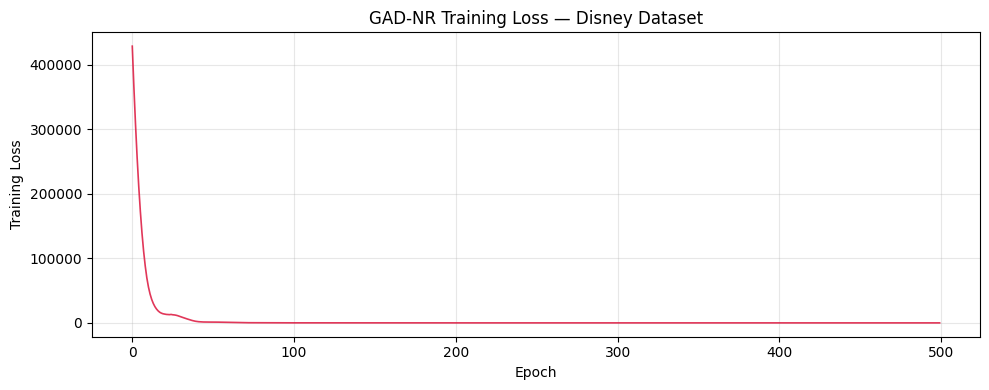


=== GAD-NR Results: Disney Dataset ===
Anomaly Type  Best AUC (%)
    Combined         84.18
  Contextual         83.75
  Structural         65.63
  Joint-type         83.75
 Struct-type         65.36

Min training loss: 6.467850


In [11]:
# Training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_values, color='crimson', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('GAD-NR Training Loss — Disney Dataset')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_disney.png', dpi=150)
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Anomaly Type':  ['Combined', 'Contextual', 'Structural', 'Joint-type', 'Struct-type'],
    'Best AUC (%)': [round(best_auc, 2), round(best_auc_contextual, 2),
                     round(best_auc_structural, 2), round(best_auc_joint, 2),
                     round(best_auc_struct_type, 2)]
})
print('\n=== GAD-NR Results: Disney Dataset ===')
print(summary_df.to_string(index=False))
print(f'\nMin training loss: {min_loss:.6f}')